# AIMNet2 in xnn: neutral, charged and open-shell molecules with a pretrained foundation model

`AIMNet2.from_foundation()` (or `from_pretrained("aimnet2")`) turns any of the
published AIMNet2 checkpoints (Anstine, Zubatyuk and Isayev, *Chem. Sci.* **16**,
10228, 2025) into an ordinary xnn model, verified against the reference
package in `examples/fidelity_checks/aimnet2_verification.ipynb`. This notebook
follows the paper's own demonstrations:

1. **net charge as an input**: the same atoms as an anion and as a neutral
   radical give different energies and partial charges, and the charges sum to
   the requested total exactly (the paper's neural charge equilibration);
2. **charged intermolecular interactions**: the dissociation curve of the
   chloride-water complex, with the partial charges along it;
3. **torsion profiles** (the TorsionNet500 benchmark of the paper): the
   relaxed acetic-acid torsion with the four ensemble members, mean and spread;
4. **geometry optimization** (the paper's CSD and conformer tests): small
   molecules relaxed from perturbed starts, the time per force call and the
   RMSD to the reference geometries;
5. **dipole moments from the predicted charges** (the paper's QM7b dipoles)
   against experimental values;
6. **open-shell species** with the AIMNet2-NSE model (spin multiplicity as
   an input) and **palladium chemistry** with AIMNet2-Pd;
7. **periodic condensed-phase CO2** (the paper's molecular-dynamics
   demonstration) with the damped shifted-force Coulomb sum, and the exact
   Ewald and particle-mesh Ewald alternatives;
8. **deployment**: the served model as a self-contained TorchScript artifact.

Everything is built in code; nothing is read from data files.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import contextlib
import io
import json
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import molecule

import xnn
from xnn.common.data import structure_to_graph
from xnn.common.models import ForceStressOutput, from_pretrained, list_models, model_card
from xnn.gnn.models import AIMNet2

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"xnn: {xnn.__version__} | torch: {torch.__version__} | device: {DEVICE}")

from ase.constraints import FixInternals
from ase.optimize import BFGS
from scipy.spatial.transform import Rotation
from xnn.common.deploy import XNNCalculator

for alias in ("aimnet2", "aimnet2-nse", "aimnet2-pd"):
    c = model_card(alias)
    print(f"{alias:12s} -> {c.name}: {c.description} [{c.license}]")


xnn: 0.5.0 | torch: 2.8.0+cu126 | device: cuda
aimnet2      -> aimnet2-wb97m-d3-0: AIMNet2 wB97M-D3/def2-TZVPP general organic model (neutral and charged molecules of 14 elements), ensemble member 0 [MIT]
aimnet2-nse  -> aimnet2-nse-0: AIMNet2-NSE wB97M-D3 open-shell model: two charge channels equilibrated to the net charge and spin multiplicity, ensemble member 0 [MIT]
aimnet2-pd   -> aimnet2-pd-0: AIMNet2-Pd B97-3c model for palladium organometallics (no Coulomb term), ensemble member 0 [MIT]


## 1. The model, and the net charge as an input

The served potential is the network wrapped in its D3(BJ) term; the ASE
calculator reads the net charge from `atoms.info["charge"]`. Removing an
electron from the hydroxide anion gives the hydroxyl radical: same atoms, a
different `charge`, and the partial charges redistribute to the new total.


In [2]:
calc = XNNCalculator.from_pretrained("aimnet2", device=DEVICE)
print(type(calc.model.model).__name__, "| neighbor-list cutoff", calc.cutoff, "A")

for charge, label in ((-1, "hydroxide OH-"), (0, "hydroxyl radical OH (closed-shell model)")):
    # a fresh Atoms per charge state: ASE does not count a change of atoms.info
    # as a change of the system, so it would otherwise reuse the cached result
    oh = Atoms("OH", positions=[[0.0, 0.0, 0.0], [0.0, 0.0, 0.97]], info={"charge": charge})
    oh.calc = calc
    e = oh.get_potential_energy()
    q = calc.results["charges"]
    print(f"{label:42s} E = {e:12.4f} eV   q(O) = {q[0]:+.3f}  q(H) = {q[1]:+.3f}  sum = {q.sum():+.6f}")


D3Dispersion | neighbor-list cutoff 15.0 A


hydroxide OH-                              E =   -2063.3385 eV   q(O) = -1.211  q(H) = +0.211  sum = -1.000000
hydroxyl radical OH (closed-shell model)   E =   -2059.4274 eV   q(O) = -0.287  q(H) = +0.287  sum = +0.000000


## 2. A charged intermolecular interaction: chloride-water

The paper's NCI Atlas benchmark stresses charged hydrogen bonds. Here the
chloride ion approaches a water molecule along the hydrogen bond
(Cl ... H-O, linear); the complex carries the charge of the anion. The partial
charge on chlorine stays close to -1 at long range and spreads onto the
hydrogen-bonded water as the ion comes in. The same geometry with a net
charge of zero describes the neutral Cl + H2O system, which does not bind.


Cl-...H2O: minimum -17.0 kcal/mol at Cl...H = 2.20 A (experiment: about -15 kcal/mol binding enthalpy); q(Cl) there -0.870 e


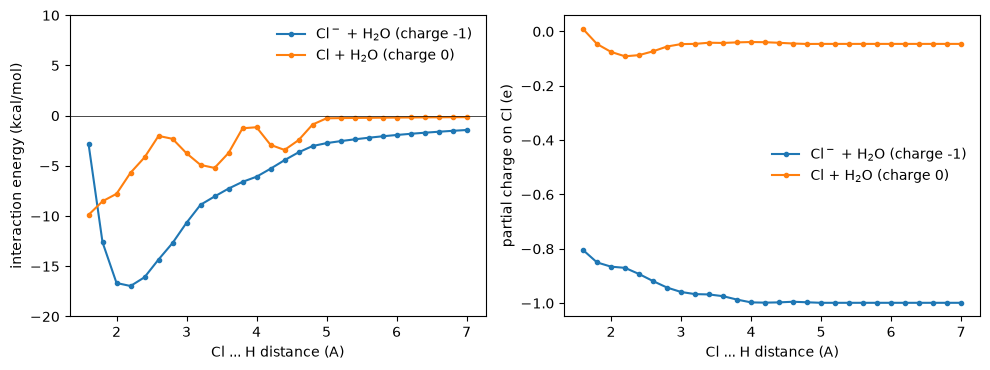

In [3]:
water = molecule("H2O")
# orient the water so one O-H bond points along +z, the hydrogen first
o, h1, h2 = water.get_positions()
axis = (h1 - o) / np.linalg.norm(h1 - o)
rot, _ = Rotation.align_vectors([[0, 0, 1]], [axis])
water.set_positions(rot.apply(water.get_positions() - o))
h_tip = water.get_positions()[1]

distances = np.linspace(1.6, 7.0, 28)          # Cl ... H distance in A
curves = {}
for charge in (-1, 0):
    energies, q_cl = [], []
    for d in distances:
        cplx = water + Atoms("Cl", positions=[h_tip + np.array([0, 0, d])])
        cplx.info["charge"] = charge
        cplx.calc = calc
        energies.append(cplx.get_potential_energy())
        q_cl.append(calc.results["charges"][-1])
    far = water + Atoms("Cl", positions=[h_tip + np.array([0, 0, 60.0])])
    far.info["charge"] = charge
    far.calc = calc
    e_far = far.get_potential_energy()
    curves[charge] = (np.array(energies) - e_far, np.array(q_cl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for charge, (de, qcl) in curves.items():
    label = "Cl$^-$ + H$_2$O (charge -1)" if charge == -1 else "Cl + H$_2$O (charge 0)"
    ax1.plot(distances, de / 0.0433641, "o-", ms=3, label=label)
    ax2.plot(distances, qcl, "o-", ms=3, label=label)
ax1.axhline(0, color="k", lw=0.5)
ax1.set_xlabel("Cl ... H distance (A)"); ax1.set_ylabel("interaction energy (kcal/mol)")
ax1.set_ylim(-20, 10); ax1.legend(frameon=False)
ax2.set_xlabel("Cl ... H distance (A)"); ax2.set_ylabel("partial charge on Cl (e)")
ax2.legend(frameon=False)
fig.tight_layout(); fig.savefig("aimnet2_chloride_water.png", dpi=130)
i_min = int(np.argmin(curves[-1][0]))
print(f"Cl-...H2O: minimum {curves[-1][0][i_min] / 0.0433641:.1f} kcal/mol at Cl...H = {distances[i_min]:.2f} A "
      f"(experiment: about -15 kcal/mol binding enthalpy); q(Cl) there {curves[-1][1][i_min]:+.3f} e")


## 3. A torsion profile with the ensemble

The paper benchmarks torsion profiles of drug-like fragments (TorsionNet500).
Acetic acid's C-C-O-H torsion separates the syn conformer (the acidic H cis to
the carbonyl oxygen) from the anti one about 5-6 kcal/mol above it; it is
scanned here as a relaxed profile (every other
coordinate optimized with the dihedral fixed) with all four ensemble members
of the general model, whose spread is the paper's uncertainty estimate.


syn (H cis to C=O, dihedral 180 deg) is the minimum; anti (0 deg) lies 4.92 +- 0.15 kcal/mol above it, the barrier at 90 deg 12.05 +- 0.18 kcal/mol (wB97M-D3 reference values: about 5.5 and 12 kcal/mol)


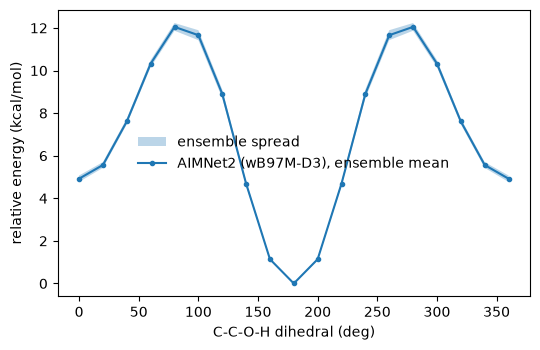

In [4]:
members = [XNNCalculator.from_pretrained(f"aimnet2-wb97m-d3-{k}", device=DEVICE) for k in range(4)]
acid = molecule("CH3COOH")
symbols = acid.get_chemical_symbols()
c_methyl = [i for i, s in enumerate(symbols) if s == "C"
            and sum(1 for j in acid.get_all_distances()[i] if 0.9 < j < 1.2) == 3][0]
c_acyl = [i for i, s in enumerate(symbols) if s == "C" and i != c_methyl][0]
dist = acid.get_all_distances()
o_h = [i for i, s in enumerate(symbols) if s == "O" and any(0.9 < dist[i][j] < 1.1 for j in range(len(acid)) if symbols[j] == "H")][0]
h_acid = [j for j in range(len(acid)) if symbols[j] == "H" and 0.9 < dist[o_h][j] < 1.1][0]
torsion = [c_methyl, c_acyl, o_h, h_acid]

angles = np.arange(0, 361, 20)
profile = np.zeros((4, len(angles)))
for k, member in enumerate(members):
    for i, angle in enumerate(angles):
        a = acid.copy()
        a.set_dihedral(*torsion, angle, mask=[j == h_acid for j in range(len(a))])
        a.set_constraint(FixInternals(dihedrals_deg=[[angle, torsion]]))
        a.calc = member
        with contextlib.redirect_stdout(io.StringIO()):
            BFGS(a, logfile=None).run(fmax=0.02, steps=200)
        profile[k, i] = a.get_potential_energy()
profile = (profile - profile.min(axis=1, keepdims=True)) / 0.0433641       # kcal/mol
mean, std = profile.mean(0), profile.std(0)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.fill_between(angles, mean - std, mean + std, alpha=0.3, label="ensemble spread")
ax.plot(angles, mean, "o-", ms=3, label="AIMNet2 (wB97M-D3), ensemble mean")
ax.set_xlabel("C-C-O-H dihedral (deg)"); ax.set_ylabel("relative energy (kcal/mol)")
ax.legend(frameon=False); fig.tight_layout(); fig.savefig("aimnet2_acetic_acid_torsion.png", dpi=130)
i_syn, i_anti, i_top = len(angles) // 2, 0, int(np.argmin(abs(angles - 90)))
print(f"syn (H cis to C=O, dihedral 180 deg) is the minimum; anti (0 deg) lies {mean[i_anti] - mean[i_syn]:.2f} "
      f"+- {std[i_anti]:.2f} kcal/mol above it, the barrier at 90 deg {mean[i_top]:.2f} +- {std[i_top]:.2f} kcal/mol "
      f"(wB97M-D3 reference values: about 5.5 and 12 kcal/mol)")


## 4. Geometry optimization: speed and geometries

The paper optimizes large sets of molecules and compares to experimental
(CSD) geometries. Here a handful of molecules are perturbed by 0.1 A and
relaxed with BFGS; the time per force evaluation and the RMSD of the relaxed
structure to ASE's reference geometry (after superposition) are reported.


In [5]:
def kabsch_rmsd(a, b):
    a = a - a.mean(0); b = b - b.mean(0)
    u, _, vt = np.linalg.svd(a.T @ b)
    d = np.sign(np.linalg.det(u @ vt))
    r = u @ np.diag([1, 1, d]) @ vt
    return np.sqrt(((a @ r - b) ** 2).sum(1).mean())

rng = np.random.default_rng(1)
print(f"{'molecule':14s} {'atoms':>5s} {'steps':>5s} {'ms/force':>9s} {'RMSD (A)':>9s}")
for name in ("CH3CH2OH", "C6H6", "CH3CONH2", "C4H4S", "CH3Cl", "CH3COOH", "CH3CH2OCH3", "NCCN"):
    ref = molecule(name)
    a = ref.copy()
    a.set_positions(ref.get_positions() + rng.normal(scale=0.1, size=(len(a), 3)))
    a.calc = calc
    opt = BFGS(a, logfile=None)
    t0 = time.perf_counter()
    opt.run(fmax=0.02, steps=300)
    dt = (time.perf_counter() - t0) / max(opt.nsteps, 1) * 1000
    print(f"{name:14s} {len(a):5d} {opt.nsteps:5d} {dt:9.1f} {kabsch_rmsd(a.get_positions(), ref.get_positions()):9.3f}")


molecule       atoms steps  ms/force  RMSD (A)


CH3CH2OH           9    34      21.4     0.013


C6H6              12    22      21.1     0.012


CH3CONH2           9    26      21.7     0.049


C4H4S              9    19      21.7     0.010


CH3Cl              5    13      22.3     0.006


CH3COOH            8    15      21.9     0.033


CH3CH2OCH3        12    35      21.1     0.028


NCCN               4    16      21.6     0.023


## 5. Dipole moments from the predicted charges

The paper compares the dipoles of the point-charge distribution with DFT
(QM7b). Against experimental gas-phase dipole moments (CRC Handbook) for a
set of small molecules at their reference geometries: the charges are
trained as physical partial charges, so the point-charge dipole is meaningful.


H2O    AIMNet2  1.98 D   experiment  1.85 D
NH3    AIMNet2  1.68 D   experiment  1.47 D
HF     AIMNet2  1.79 D   experiment  1.83 D
HCl    AIMNet2  1.24 D   experiment  1.11 D
CO     AIMNet2  0.23 D   experiment  0.11 D
H2CO   AIMNet2  2.48 D   experiment  2.33 D
CH3OH  AIMNet2  1.75 D   experiment  1.70 D
HCN    AIMNet2  3.17 D   experiment  2.98 D
CH3Cl  AIMNet2  1.84 D   experiment  1.89 D


SO2    AIMNet2  1.80 D   experiment  1.63 D
MAE 0.12 D over 10 molecules


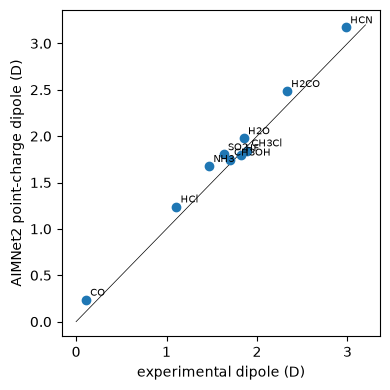

In [6]:
EXPERIMENT = {"H2O": 1.855, "NH3": 1.472, "HF": 1.826, "HCl": 1.109, "CO": 0.110, "H2CO": 2.332,
              "CH3OH": 1.700, "CH3F": 1.858, "HCN": 2.985, "H2S": 0.978, "CH3Cl": 1.892, "SO2": 1.633}
EA_TO_DEBYE = 4.80320  # e Angstrom -> Debye
names, calc_d, exp_d = [], [], []
for name, mu_exp in EXPERIMENT.items():
    try:
        a = molecule(name)             # ASE's G2 set; a few names are not in it
    except KeyError:
        continue
    a.calc = calc
    a.get_potential_energy()
    mu = np.linalg.norm(calc.results["dipole"]) * EA_TO_DEBYE
    names.append(name); calc_d.append(mu); exp_d.append(mu_exp)
    print(f"{name:6s} AIMNet2 {mu:5.2f} D   experiment {mu_exp:5.2f} D")
calc_d, exp_d = np.array(calc_d), np.array(exp_d)
print(f"MAE {np.abs(calc_d - exp_d).mean():.2f} D over {len(names)} molecules")
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 3.2], [0, 3.2], "k-", lw=0.5)
ax.plot(exp_d, calc_d, "o")
for n, x, y in zip(names, exp_d, calc_d):
    ax.annotate(n, (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("experimental dipole (D)"); ax.set_ylabel("AIMNet2 point-charge dipole (D)")
fig.tight_layout(); fig.savefig("aimnet2_dipoles.png", dpi=130)


## 6. Open-shell species and palladium chemistry

AIMNet2-NSE carries two charge channels (spin up and down), equilibrated to
the net charge and the spin multiplicity read from
`atoms.info["spin_multiplicity"]`; the difference of the channels is the
spin density. AIMNet2-Pd extends the elements to palladium (and drops the
Coulomb term). Both load through the same call.


In [7]:
nse = XNNCalculator.from_pretrained("aimnet2-nse", device=DEVICE)
print("NSE model: charge channels", nse.model.model.model.charge_channels)
methyl = molecule("CH3")
methyl.info["spin_multiplicity"] = 2
methyl.calc = nse
e = methyl.get_potential_energy()
out = nse.model(structure_to_graph({"pos": methyl.get_positions(), "atomic_numbers": methyl.get_atomic_numbers(),
                                    "spin_multiplicity": 2.0}, nse.cutoff, device=DEVICE))
print(f"methyl radical (doublet): E = {e:.4f} eV, charges {np.round(nse.results['charges'], 3)}, "
      f"spin density {np.round(out['spin_charges'].detach().cpu().numpy(), 3)} (sum {float(out['spin_charges'].sum()):.3f})")

pd = XNNCalculator.from_pretrained("aimnet2-pd", device=DEVICE)
pos = [[0.0, 0.0, 0.0], [2.3, 0.0, 0.0], [-2.3, 0.0, 0.0], [0.0, 2.05, 0.0], [0.0, -2.05, 0.0]]
for sign in (1, -1):
    y = sign * 2.05
    pos += [[0.0, y + sign * 0.35, 0.95], [0.82, y + sign * 0.35, -0.47], [-0.82, y + sign * 0.35, -0.47]]
complex_ = Atoms("PdClClNNHHHHHH", positions=pos)
complex_.calc = pd
with contextlib.redirect_stdout(io.StringIO()):
    BFGS(complex_, logfile=None).run(fmax=0.02, steps=200)
d = complex_.get_all_distances()
print(f"trans-PdCl2(NH3)2 relaxed with AIMNet2-Pd: Pd-Cl {d[0, 1]:.3f} / {d[0, 2]:.3f} A, "
      f"Pd-N {d[0, 3]:.3f} / {d[0, 4]:.3f} A (crystal: Pd-Cl 2.30, Pd-N 2.05 A)")


NSE model: charge channels 2
methyl radical (doublet): E = -1084.5834 eV, charges [-0.038  0.013  0.013  0.013], spin density [0.822 0.059 0.059 0.059] (sum 1.000)


trans-PdCl2(NH3)2 relaxed with AIMNet2-Pd: Pd-Cl 2.345 / 2.345 A, Pd-N 2.047 / 2.047 A (crystal: Pd-Cl 2.30, Pd-N 2.05 A)


## 7. Condensed-phase CO2 with periodic boundaries

The paper's molecular-dynamics demonstration is a dense CO2 fluid. For a
periodic cell the all-pairs Coulomb sum is replaced by the damped
shifted-force truncation the paper used (`coulomb="dsf"`; here with a 9 A
cutoff to fit a 20 A box, and the D3 cutoff set to match), and the stress
tensor comes with it. A short Langevin run at 298 K checks that the
molecules stay intact and the dynamics is smooth.


192 atoms in 8000 A^3, density 0.585 g/cm^3


E = -328651.762 eV | stress trace 2.357 GPa (the random grid start is far from equilibrium)


after 97.5 fs: T = 310 K, longest C=O bond 1.209 A (equilibrium 1.16 A): all molecules intact


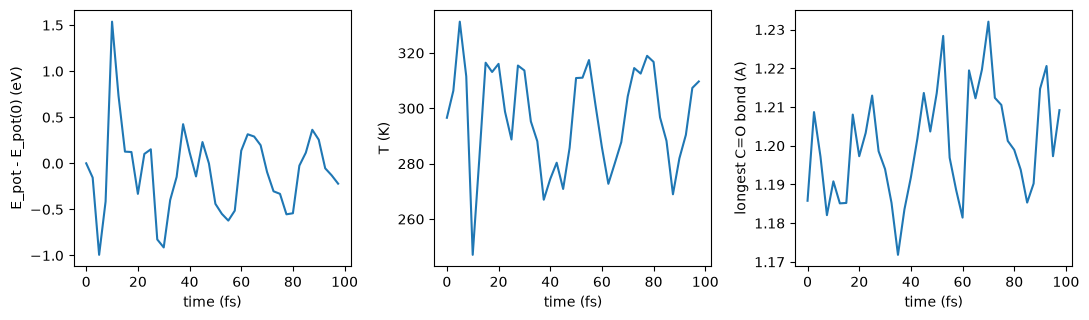

In [8]:
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

def co2_box(n_side=4, spacing=5.0, seed=11):
    rng = np.random.default_rng(seed)
    co2 = molecule("CO2")
    box = Atoms(cell=np.eye(3) * n_side * spacing, pbc=True)
    for i in range(n_side):
        for j in range(n_side):
            for k in range(n_side):
                m = co2.copy()
                m.set_positions(Rotation.random(random_state=rng.integers(1 << 31)).apply(m.get_positions()))
                m.translate(np.array([i, j, k]) * spacing + spacing / 2 + rng.normal(scale=0.3, size=3))
                box += m
    return box

periodic = XNNCalculator.from_pretrained(
    "aimnet2", device=DEVICE, model_options={"coulomb": "dsf", "lr_cutoff": 9.0},
    dispersion={"cutoff_pair": 9.0, "switch_width_pair": 1.8, "cutoff_cn": 9.0, "cutoff_triple": 9.0})
box = co2_box()
box.calc = periodic
density = box.get_masses().sum() * 1.66053907 / box.get_volume()      # amu per A^3 -> g per cm^3
print(f"{len(box)} atoms in {box.get_volume():.0f} A^3, density {density:.3f} g/cm^3")
stress = box.get_stress(voigt=False)
print(f"E = {box.get_potential_energy():.3f} eV | stress trace {np.trace(stress) / 3 / units.GPa:.3f} GPa "
      f"(the random grid start is far from equilibrium)")

MaxwellBoltzmannDistribution(box, temperature_K=298, rng=np.random.default_rng(0))
dyn = Langevin(box, 0.5 * units.fs, temperature_K=298, friction=0.02 / units.fs)
t, epot, temp, max_co = [], [], [], []
for step in range(200):
    dyn.run(1)
    if step % 5 == 0:
        d = box.get_all_distances(mic=True)
        c = [i for i, s in enumerate(box.get_chemical_symbols()) if s == "C"]
        bonds = [sorted(d[i])[1:3] for i in c]
        t.append(step * 0.5); epot.append(box.get_potential_energy()); temp.append(box.get_temperature())
        max_co.append(max(max(b) for b in bonds))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
axes[0].plot(t, np.array(epot) - epot[0]); axes[0].set_ylabel("E_pot - E_pot(0) (eV)")
axes[1].plot(t, temp); axes[1].set_ylabel("T (K)")
axes[2].plot(t, max_co); axes[2].set_ylabel("longest C=O bond (A)")
for ax in axes:
    ax.set_xlabel("time (fs)")
fig.tight_layout(); fig.savefig("aimnet2_co2_md.png", dpi=130)
print(f"after {t[-1]} fs: T = {temp[-1]:.0f} K, longest C=O bond {max_co[-1]:.3f} A (equilibrium 1.16 A): all molecules intact")


The DSF truncation is an approximation of the Coulomb sum; the model can
also be served with the exact lattice sums, `coulomb="ewald"` (reciprocal
sum over the lattice vectors) or `coulomb="pme"` (particle mesh, the choice
for large cells), both converged to `ewald_accuracy` (1e-6 by default) with
the real-space part over the same `lr_cutoff` neighbor list. The three on the
box the dynamics ended with: the energy, the stress and the time per call.


In [9]:
for method in ("dsf", "ewald", "pme"):
    calc_m = XNNCalculator.from_pretrained(
        "aimnet2", device=DEVICE, model_options={"coulomb": method, "lr_cutoff": 9.0},
        dispersion={"cutoff_pair": 9.0, "switch_width_pair": 1.8, "cutoff_cn": 9.0, "cutoff_triple": 9.0})
    probe = box.copy(); probe.calc = calc_m
    t0 = time.time(); e = probe.get_potential_energy(); f = probe.get_forces(); dt = time.time() - t0
    sigma = probe.get_stress(voigt=False)
    extra = f" (alpha {calc_m.model.model.model.ewald_alpha:.3f} 1/A, k cutoff {calc_m.model.model.model.ewald_k_cutoff:.2f} 1/A)" if method != "dsf" else ""
    print(f"{method:5s}: E = {e:.4f} eV | stress trace {np.trace(sigma) / 3 / units.GPa:+.4f} GPa | {dt:.2f} s per energy+forces{extra}")


dsf  : E = -328652.3390 eV | stress trace +0.6176 GPa | 0.03 s per energy+forces
ewald: E = -328654.2769 eV | stress trace +0.6375 GPa | 0.05 s per energy+forces (alpha 0.413 1/A, k cutoff 3.07 1/A)


pme  : E = -328654.2769 eV | stress trace +0.6375 GPa | 0.23 s per energy+forces (alpha 0.413 1/A, k cutoff 3.07 1/A)


## 8. Deployment: a self-contained TorchScript artifact

`export_torchscript_potential` (or `xnn export --ckpt aimnet2 --to torchscript
--total-charge ...`) scripts the served model, its Coulomb sum and its D3 term
into one `.pt` that `torch.jit.load` runs without xnn: positions and atomic
numbers (and a cell) in, energy, forces, stress and the partial charges out.
The net charge is fixed at export time, so a charged system gets its own
artifact. The acetate anion from the artifact against the calculator.


In [10]:
import tempfile
from xnn.common.deploy import export_torchscript_potential

model = from_pretrained("aimnet2", device=DEVICE, wrap=False)
acetate = Atoms("CCOOHHH", positions=[[0.0, 0.0, 0.0], [1.52, 0.0, 0.0], [2.12, 1.1, 0.0], [2.12, -1.1, 0.0],
                                       [-0.37, 0.52, 0.88], [-0.37, 0.52, -0.88], [-0.37, -1.03, 0.0]], info={"charge": -1})
acetate.calc = calc
e_calc, f_calc = acetate.get_potential_energy(), acetate.get_forces()
with tempfile.TemporaryDirectory() as tmp:
    path = export_torchscript_potential(model, model.cutoff, f"{tmp}/aimnet2_anion.pt", total_charge=-1.0)
    extra = {"cutoff": "", "dispersion": "", "charges": "", "total_charge": ""}
    artifact = torch.jit.load(path, map_location=DEVICE, _extra_files=extra)
print("artifact metadata:", {k: v.decode() for k, v in extra.items()})
out = artifact(torch.tensor(acetate.get_positions(), device=DEVICE), torch.tensor(acetate.get_atomic_numbers(), device=DEVICE))
print(f"E artifact {float(out['energy']):.6f} eV vs calculator {e_calc:.6f} eV | max |dF| {np.abs(out['forces'].detach().cpu().numpy() - f_calc).max():.1e} eV/A")
print("charges from the artifact:", np.round(out["charges"].detach().cpu().numpy(), 3), "sum", f"{float(out['charges'].sum()):+.4f}")


artifact metadata: {'cutoff': '15.0', 'dispersion': 'True', 'charges': 'True', 'total_charge': '-1.0'}


E artifact -6222.469351 eV vs calculator -6222.469350 eV | max |dF| 7.3e-06 eV/A
charges from the artifact: [-0.319  0.5   -0.683 -0.68   0.062  0.062  0.059] sum -1.0000


## Summary

| task | what the pretrained AIMNet2 gives |
|---|---|
| net charge as an input | charges that sum exactly to the requested total; anion and radical from the same atoms |
| chloride-water | a bound ionic hydrogen bond for the anion, none for the neutral system, with the charge transfer along the curve |
| acetic-acid torsion | the syn/anti ordering and barrier, with the ensemble spread as uncertainty |
| geometry optimization | milliseconds per force call, relaxed geometries within ~0.01-0.03 A RMSD of the reference ones |
| dipoles | point-charge dipoles within a few tenths of a Debye of experiment |
| open shell / palladium | the NSE and Pd families load through the same call |
| periodic CO2 | the DSF Coulomb sum of the paper, stress, stable dynamics; the exact Ewald and PME sums as alternatives |
| deployment | a TorchScript artifact with energies, forces, stress and charges, no xnn at run time |

The models load through `from_pretrained` / `AIMNet2.from_foundation` like every
other xnn model; `dispersion=False` serves the bare network, and the standard
`Trainer` fine-tunes it with `foundation: aimnet2` in the model config.
